In [ ]:
!pip install timm -q

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [ ]:
warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

DATA_DIR="/content/drive/MyDrive/research_data"

CHECKPOINT_PATH=os.path.join(DATA_DIR,"checkpoint_deit_small.pth")
BEST_MODEL_PATH=os.path.join(DATA_DIR,"best_deit_small.pth")

cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_df=pd.read_csv(DATA_DIR+"/train.csv")
val_df=pd.read_csv(DATA_DIR+"/val.csv")
test_df=pd.read_csv(DATA_DIR+"/test.csv")

print(len(train_df),len(val_df),len(test_df))

8470 1815 1815


In [ ]:
IMG_SIZE=224
BATCH_SIZE=32

train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [ ]:
class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        # Image path
        img_path = self.df.loc[idx, "image_path"]

        # Label
        label = self.df.loc[idx, "label"]

        # Convert label to integer
        # fake -> 0
        # real -> 1
        if label == "real":
            label = 1
        else:
            label = 0

        # Read image
        image = Image.open(img_path).convert("RGB")

        # Apply transforms
        if self.transform is not None:
            image = self.transform(image)

        # Return image and label
        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
train_dataset = BrainDataset(train_df, train_transform)
val_dataset   = BrainDataset(val_df, test_transform)
test_dataset  = BrainDataset(test_df, test_transform)

print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("Test Dataset :", len(test_dataset))

Train Dataset : 8470
Validation Dataset : 1815
Test Dataset : 1815


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("Train batches :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches : 265
Validation batches : 57
Test batches : 57


In [ ]:
NUM_CLASSES = 2

model = timm.create_model(
    "deit_small_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

print(model)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

print("Loss, Optimizer and Scheduler Ready")

Loss, Optimizer and Scheduler Ready


In [ ]:
import os
import torch

start_epoch = 0
best_val_acc = 0.0

if os.path.exists(CHECKPOINT_PATH):

    checkpoint = torch.load(CHECKPOINT_PATH)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]

    print("="*60)
    print("✅ Checkpoint Found")
    print(f"Resuming from Epoch {start_epoch}")
    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print("="*60)

else:

    print("="*60)
    print("No Checkpoint Found")
    print("Training will start from Epoch 1")
    print("="*60)

No Checkpoint Found
Training will start from Epoch 1


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch

num_epochs = 5

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(start_epoch, num_epochs):

    print("=" * 60)
    print(f"Epoch {epoch+1}/{num_epochs}")

    # ==========================
    # Training
    # ==========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):

        if batch_idx % 20 == 0:
            print(f"Training Batch {batch_idx}/{len(train_loader)}")

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ==========================
    # Validation
    # ==========================

    model.eval()

    val_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch_idx, (images, labels) in enumerate(val_loader):

            if batch_idx % 10 == 0:
                print(f"Validation Batch {batch_idx}/{len(val_loader)}")

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_loss / len(val_loader)

    val_acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    scheduler.step(val_acc)

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print("-" * 40)
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")

    # Save Best Model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print("✅ Best Model Saved")

    # Save Checkpoint
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
        },
        CHECKPOINT_PATH,
    )

    print("💾 Checkpoint Saved")

print("=" * 60)
print("Training Completed!")
print(f"Best Validation Accuracy : {best_val_acc:.4f}")

Epoch 1/5
Training Batch 0/265
Training Batch 20/265
Training Batch 40/265
Training Batch 60/265
Training Batch 80/265
Training Batch 100/265
Training Batch 120/265
Training Batch 140/265
Training Batch 160/265
Training Batch 180/265
Training Batch 200/265
Training Batch 220/265
Training Batch 240/265
Training Batch 260/265
Validation Batch 0/57
Validation Batch 10/57
Validation Batch 20/57
Validation Batch 30/57
Validation Batch 40/57
Validation Batch 50/57
----------------------------------------
Train Loss : 0.3851
Train Acc  : 0.8374
Val Loss   : 0.2727
Val Acc    : 0.9085
Precision  : 0.9740
Recall     : 0.8000
F1 Score   : 0.8785
✅ Best Model Saved
💾 Checkpoint Saved
Epoch 2/5
Training Batch 0/265
Training Batch 20/265
Training Batch 40/265
Training Batch 60/265
Training Batch 80/265
Training Batch 100/265
Training Batch 120/265
Training Batch 140/265
Training Batch 160/265
Training Batch 180/265
Training Batch 200/265
Training Batch 220/265
Training Batch 240/265
Training Batch 

Loading Best DeiT-Small Model
FINAL TEST RESULTS
Accuracy  : 0.9212
Precision : 0.9919
Recall    : 0.8160
F1 Score  : 0.8954
AUC Score : 0.9239

Classification Report

              precision    recall  f1-score   support

           0       0.88      1.00      0.94      1065
           1       0.99      0.82      0.90       750

    accuracy                           0.92      1815
   macro avg       0.94      0.91      0.92      1815
weighted avg       0.93      0.92      0.92      1815



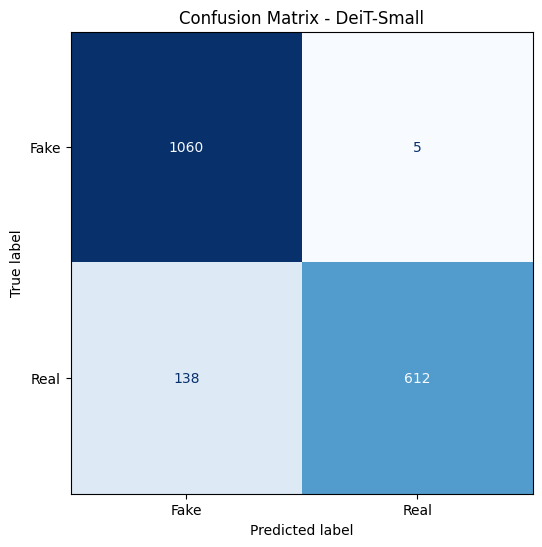

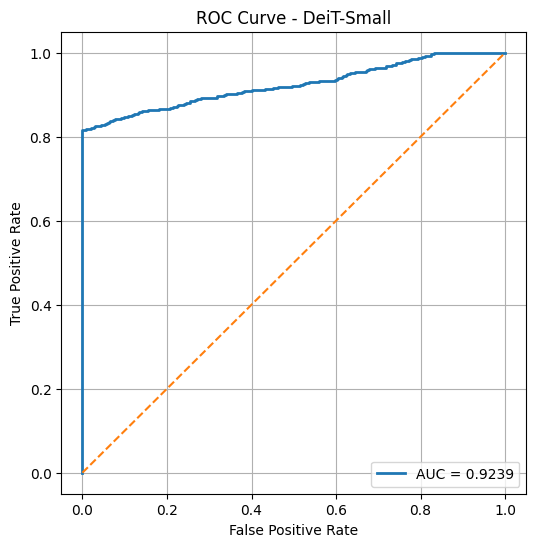

Evaluation Completed Successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

print("="*60)
print("Loading Best DeiT-Small Model")
print("="*60)

checkpoint = torch.load(BEST_MODEL_PATH)

# Handle both checkpoint dict and plain state_dict
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ===========================
# Metrics
# ===========================

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
auc_score = roc_auc_score(all_labels, all_probs)

print("="*60)
print("FINAL TEST RESULTS")
print("="*60)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC Score : {auc_score:.4f}")

print("\nClassification Report\n")
print(classification_report(all_labels, all_preds))

# ===========================
# Confusion Matrix
# ===========================

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "Real"]
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - DeiT-Small")
plt.show()

# ===========================
# ROC Curve
# ===========================

fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DeiT-Small")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("="*60)
print("Evaluation Completed Successfully!")
print("="*60)